# Hash Pipeline: Log Generation → BCH48 Encoding → Decoding

이 노트북은 전체 파이프라인을 단계별로 실행합니다.

1. **Configuration** — 설정 초기화  
2. **Hash Log Generation** — 랜덤 입력 → MD5 → JSON 로그 저장  
3. **BCH48 Image Encoding** — JSON 로그 → BCH48 인코딩 → PNG 저장  
4. **Image Decoding** — PNG 픽셀 샘플링 → BCH48 디코딩 + 신뢰도 반환  
5. **Bulk Decode** — 전체 PNG 일괄 처리  
6. **Visualization** — 인코딩 이미지 및 디코딩 결과 시각화

## 0. Environment

In [1]:
import os
import sys
import tempfile

os.environ.setdefault('MPLCONFIGDIR', os.path.join(tempfile.gettempdir(), 'matplotlib-cache'))
os.makedirs(os.environ['MPLCONFIGDIR'], exist_ok=True)

# Ensure src/ is on the path when running outside the installed package
_repo_src = os.path.normpath(os.path.join(os.getcwd(), '..', 'src'))
if _repo_src not in sys.path:
    sys.path.insert(0, _repo_src)

import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

print('Python:', sys.version.split()[0])
print('Working directory:', os.getcwd())

Python: 3.12.3
Working directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/notebooks


## 1. Configuration

| 플래그 | 기본값 | 설명 |
|--------|--------|------|
| `RUN_HASH_JSON` | `True` | 입력 생성 + MD5 + JSON 로그 저장 |
| `RUN_PNG` | `True` | JSON 로그 → BCH48 PNG 생성 |
| `RUN_HDF5` | `False` | PNG → HDF5 텐서 샤드 생성 |
| `ITERATION` | `10` | 생성할 해시 / 이미지 수 |

> 기존 로그 재사용: `RUN_HASH_JSON=False`, `RUN_PNG=True`

In [2]:
from diffusion_hash_inv.config import (
    MainConfig, HashConfig, MessageConfig, OutputConfig, Byte2RGBConfig
)
from diffusion_hash_inv.main import MainEP, RuntimeConfig

# ── Run flags ─────────────────────────────────────────────────────────────
RUN_HASH_JSON = True   # JSON 로그 생성 여부
RUN_PNG       = True   # PNG 이미지 생성 여부
RUN_HDF5      = False  # HDF5 텐서 생성 여부

ITERATION = 10_000         # 생성할 해시 / 이미지 수
VERBOSE   = False

# 16 bytes = 128-bit MD5 hash output
grid_num = 4
length   = grid_num * grid_num * 8   # 128 bits

main_cfg    = MainConfig(
    verbose_flag=VERBOSE,
    clean_flag=True,
    debug_flag=False,
    make_image_flag=RUN_PNG or RUN_HDF5,
    image_workers=1,
)
message_cfg = MessageConfig(
    message_flag=False,  # False = N-bit random generation (required)
    length=length,
    random_flag=True,
    seed_flag=True,
)
hash_cfg    = HashConfig(hash_alg='MD5', length=length)
output_cfg  = OutputConfig()
rgb_cfg     = Byte2RGBConfig()  # encoding='bch48' by default

runtime_cfg = RuntimeConfig(
    main=main_cfg,
    message=message_cfg,
    hash=hash_cfg,
    output=output_cfg,
    rgb=rgb_cfg,
)
print(runtime_cfg)
print()
print('Encoding mode:', rgb_cfg.encoding)

RuntimeConfig
  MainConfig
    verbose_flag: False,
    clean_flag: True,
    debug_flag: False,
    make_image_flag: True,
    image_workers: 1,
  MessageConfig
    message_flag: False,
    length: 128,
    random_flag: True,
    seed_flag: True,
    input_seed: None,
    seed: 1284846528
  HashConfig
    hash_alg: MD5,
    length: 128,
    byteorder: little,
    word_size: 32,
    block_size: 512,
    mask: 0xFFFFFFFF,
    hierarchy: ('Step', 'Round', 'Loop')
  OutputConfig
    Root Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse,
    Data Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data,
    Output Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output,
    EMNIST Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/EMNIST,
    Encoding: 'utf-8'
  Byte2RGBConfig
    fr_min: 0,
    fr_max: 255,
    encoding: bch48,
    bin_width: 36 (legacy, unused by Golay encoder),
    bin_num: 7 (legacy,

## 2. Hash Log Generation

`MainEP.run()` 으로 입력 → MD5 → JSON 로그를 생성합니다.  
각 JSON 파일에는 **입력 메시지**, **최종 해시값**, **중간 단계 로그**가 저장됩니다.

In [3]:
main_ep = MainEP(runtime_config=runtime_cfg)

Main Entry Point Initialized.
Program Start Time: 2026-05-20 05:44:11.458696+09:00
Hash Algorithm: MD5
Message Length: 128
Data Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data
Output Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output
Clearing generated files...



In [4]:
if RUN_HASH_JSON:
    main_ep.run(
        iteration=ITERATION,
        run_hash_json=True,
        run_png=False,
        run_hdf5=False,
    )
    print('Hash/JSON generation completed.')
else:
    print('Hash/JSON generation skipped (RUN_HASH_JSON=False).')

Hash Generation Progress: 0/10000 iteration
Hash Generation Progress: 6178/10000 iteration Hash Algorithm=MD5 Message Length=128
Hash Generation Progress: 10000/10000 iteration Hash Algorithm=MD5 Message Length=128
Hash Generation Progress: done 10000/10000 iteration Hash Algorithm=MD5 Message Length=128
Hash Calculation time: 8 s, 128 ms, 401 us, 959 ns
Hash/json generation completed.

PNG image generation skipped.

HDF5 tensor generation skipped.

Total Execution Time: 8 s, 128 ms, 441 us, 708 ns

Hash/JSON generation completed.


In [5]:
# 생성된 JSON 로그 확인 (최신 run만 사용)
from diffusion_hash_inv.logger import Logs

json_dir = output_cfg.output_dir / 'json'
# 최신 타임스탬프 하위 디렉터리만 선택
_json_subdirs = sorted([d for d in json_dir.iterdir() if d.is_dir()])
_latest_json_dir = _json_subdirs[-1] if _json_subdirs else json_dir
json_files = sorted(_latest_json_dir.rglob('*.json'))
print('Latest run dir :', _latest_json_dir.name)
print('JSON log count :', len(json_files))

if json_files:
    sample = json.loads(json_files[0].read_text())
    print('\n[Sample log keys]:', list(sample.keys()))
    msg_hex = sample.get('Message', {}).get('Hex', 'N/A')
    gen_hex = sample.get('Generated hash', 'N/A')
    crt_hex = sample.get('Correct   hash', 'N/A')
    print('  message     :', msg_hex[:34], '...')
    print('  generated   :', gen_hex)
    print('  correct hash:', crt_hex)

Latest run dir : 2026-05-20 05-44-11.458696+09-00
JSON log count : 10000

[Sample log keys]: ['Metadata', 'Message', 'Generated hash', 'Correct   hash', 'Logs', 'Step Metadata']
  message     : 0x73713c0ac54181364d21b57a0738cf81 ...
  generated   : 0x87750cd0c3aae2237516cbcd7f16b99e
  correct hash: 0x87750cd0c3aae2237516cbcd7f16b99e


## 3. BCH48 Image Encoding

JSON 로그의 각 바이트를 **BCH48 코드워드(48 bit)** 로 인코딩하고,  
두 개의 RGB 픽셀(RGB1=배경, RGB2=전경)로 변환하여 PNG로 저장합니다.

**이미지 레이아웃 (28×28 px 블록 기준)**

| 레이어 | 영역 | 데이터 |
|--------|------|--------|
| 배경 (Background) | 28×28 px 전체 | RGB1 = codeword[0:3] |
| 전경 (Foreground) | 중앙 14×14 px | RGB2 = codeword[3:6] |

MD5 16 바이트 → 이미지 폭 **16 × 28 = 448 px**

In [6]:
if RUN_PNG:
    artifact_main_cfg = MainConfig(
        verbose_flag=main_cfg.verbose_flag,
        clean_flag=False,
        debug_flag=main_cfg.debug_flag,
        make_image_flag=True,
        image_workers=1,
    )
    artifact_runtime_cfg = RuntimeConfig(
        main=artifact_main_cfg,
        message=message_cfg,
        hash=hash_cfg,
        output=output_cfg,
        rgb=rgb_cfg,
    )
    artifact_ep = MainEP(runtime_config=artifact_runtime_cfg)
    artifact_ep.run(
        run_hash_json=False,
        run_png=True,
        run_hdf5=RUN_HDF5,
    )
    print('PNG encoding completed.')
else:
    print('PNG encoding skipped (RUN_PNG=False).')

Main Entry Point Initialized.
Program Start Time: 2026-05-20 05:45:01.492442+09:00
Hash Algorithm: MD5
Message Length: 128
Data Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data
Output Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output
Hash/json generation skipped.

RGB Image Maker Module Loaded.
RGB Image Maker Initialized.
Found 10000 logs to process.
Expected 710000 PNG files (71 images per log).
Processing Logs: 0/10000 log
Writing Images: 0/710000 image
Writing Images: 1740/710000 image
Processing Logs: 25/10000 log images=1704
Writing Images: 3508/710000 image
Processing Logs: 50/10000 log images=3479
Writing Images: 5277/710000 image
Processing Logs: 75/10000 log images=5254
Writing Images: 7047/710000 image
Processing Logs: 100/10000 log images=7029
Writing Images: 8825/710000 image
Processing Logs: 126/10000 log images=8875
Writing Images: 10593/710000 image
Processing Logs: 151/10000 log images=10650
Writing Images: 12364

In [7]:
# 생성된 PNG 목록 확인 (최신 run만 사용)
img_root = output_cfg.data_dir / 'images'
# 최신 타임스탬프 prefix를 가진 디렉터리만 선택 (형식: MD5_128_<timestamp>_NNNN)
_all_img_dirs = [d for d in img_root.iterdir() if d.is_dir()]
if _all_img_dirs:
    _latest_prefix = max('_'.join(d.name.split('_')[:-1]) for d in _all_img_dirs)
    png_files = sorted(
        d / 'message.png'
        for d in _all_img_dirs
        if d.name.startswith(_latest_prefix) and (d / 'message.png').exists()
    )
else:
    png_files = []
print('Latest run prefix:', _latest_prefix)
print('message.png count:', len(png_files))

if png_files:
    with Image.open(png_files[0]) as im:
        w, h = im.size
    print('Sample image size (W x H):', w, 'x', h, 'px')
    print('  Block count :', w // 28, '(=', w, 'px /', '28 px/block)')

Latest run prefix: MD5_128_2026-05-20 05-44-11.458696+09-00
message.png count: 10000
Sample image size (W x H): 448 x 28 px
  Block count : 16 (= 448 px / 28 px/block)


## 4. Image Decoding with Confidence

저장된 PNG에서 픽셀을 샘플링하여 BCH48 디코딩을 수행합니다.  
각 바이트마다 `DecodeResult`가 반환됩니다.

| 필드 | 설명 |
|------|------|
| `valid` | 복원 성공 여부 |
| `payload` | 복원된 바이트 값 (0–255) |
| `confidence` | 신뢰도 (0.0 ~ 1.0, 오류 없음 = 1.0) |
| `errors_corrected` | 정정된 비트 오류 수 (BCH48 최대 7) |
| `uncorrectable` | 정정 불가 여부 |

In [8]:
from diffusion_hash_inv.utils.image_writer import RGBImgMaker
from diffusion_hash_inv.utils.file_io import FileIO
from diffusion_hash_inv.core import RGB

# 디코더 초기화
io_ctrl   = FileIO(main_cfg, output_cfg)
img_maker = RGBImgMaker(runtime_cfg, io_ctrl, rgb_cfg)
byte2rgb  = img_maker.byte2rgb

print('Encoding mode:', byte2rgb.rgb_config.encoding)
print('Pixels/byte  :', byte2rgb.pixels_per_byte)

RGB Image Maker Initialized.
Encoding mode: bch48
Pixels/byte  : 2


In [9]:
def decode_png(png_path):
    """
    PNG 한 장을 BCH48으로 디코딩하여 바이트별 DecodeResult dict 리스트를 반환합니다.

    각 블록(28x28 px)에서 배경 픽셀(RGB1)과 전경 픽셀(RGB2)을 샘플링하고
    decode_payload_with_confidence()로 신뢰도를 포함한 결과를 반환합니다.
    """
    with Image.open(png_path) as img:
        rows = img_maker._sample_image_rgb_rows(img)

    results = []
    for row in rows:
        for i in range(0, len(row) - 1, 2):
            rgb1, rgb2 = row[i], row[i + 1]
            dr = byte2rgb.decode_payload_with_confidence(rgb1, rgb2)
            results.append({
                'valid'            : dr.valid,
                'payload'          : dr.payload,
                'confidence'       : dr.confidence,
                'errors_corrected' : dr.errors_corrected,
                'uncorrectable'    : dr.uncorrectable,
                'method'           : dr.method,
            })
    return results

In [10]:
# 첫 번째 message.png 디코딩
if png_files:
    decode_results = decode_png(png_files[0])
    print('Decoded', len(decode_results), 'bytes from:', png_files[0].name)
    print()
    header = '{:>4}  {:>5}  {:>6}  {:>4}  {:>5}'.format('Byte', 'Hex', 'Conf', 'Errs', 'Valid')
    print(header)
    print('-' * 34)
    for idx, r in enumerate(decode_results):
        h = '0x{:02x}'.format(r['payload']) if r['payload'] is not None else 'None'
        row_str = '{:>4}  {:>5}  {:>6.3f}  {:>4}  {:>5}'.format(
            idx, h, r['confidence'], r['errors_corrected'], str(r['valid'])
        )
        print(row_str)
    print()
    valid_count = sum(1 for r in decode_results if r['valid'])
    avg_conf    = sum(r['confidence'] for r in decode_results) / len(decode_results)
    print('Valid:', valid_count, '/', len(decode_results), ' | Avg confidence:', round(avg_conf, 4))
else:
    print('No PNG files found. Run with RUN_PNG=True first.')

Decoded 16 bytes from: message.png

Byte    Hex    Conf  Errs  Valid
----------------------------------
   0   0x73   1.000     0   True
   1   0x71   1.000     0   True
   2   0x3c   1.000     0   True
   3   0x0a   1.000     0   True
   4   0xc5   1.000     0   True
   5   0x41   1.000     0   True
   6   0x81   1.000     0   True
   7   0x36   1.000     0   True
   8   0x4d   1.000     0   True
   9   0x21   1.000     0   True
  10   0xb5   1.000     0   True
  11   0x7a   1.000     0   True
  12   0x07   1.000     0   True
  13   0x38   1.000     0   True
  14   0xcf   1.000     0   True
  15   0x81   1.000     0   True

Valid: 16 / 16  | Avg confidence: 1.0


In [11]:
# JSON 로그와 디코딩 결과 대조
if png_files and json_files:
    png_parent   = png_files[0].parent.name
    matched_json = [j for j in json_files if png_parent in str(j)]
    if not matched_json:
        matched_json = json_files[:1]

    log_data     = json.loads(matched_json[0].read_text())
    # Actual JSON keys: 'Message' -> {'Hex': '0x...'}
    original_hex = log_data.get('Message', {}).get('Hex', '').lstrip('0x')

    decoded_bytes = bytes(
        r['payload'] for r in decode_results if r['payload'] is not None
    )
    decoded_hex = decoded_bytes.hex()

    print('Original (JSON) :', original_hex)
    print('Decoded  (BCH48):', decoded_hex)
    print('Match           :', original_hex.lower() == decoded_hex.lower())

Original (JSON) : 73713c0ac54181364d21b57a0738cf81
Decoded  (BCH48): 73713c0ac54181364d21b57a0738cf81
Match           : True


## 5. Bulk Decode — 전체 PNG 일괄 디코딩

발견된 모든 `message.png` 파일을 순회하여 일괄 디코딩하고 통계를 출력합니다.

In [12]:
if png_files:
    bulk_stats = []
    for p in png_files:
        try:
            res     = decode_png(p)
            n_valid = sum(1 for r in res if r['valid'])
            avg_c   = sum(r['confidence'] for r in res) / len(res) if res else 0.0
            total_e = sum(r['errors_corrected'] for r in res)
            bulk_stats.append({
                'file'        : p.name,
                'bytes'       : len(res),
                'valid'       : n_valid,
                'avg_conf'    : avg_c,
                'total_errors': total_e,
            })
        except Exception as exc:
            bulk_stats.append({'file': p.name, 'error': str(exc)})

    ok_stats  = [s for s in bulk_stats if 'error' not in s]
    err_stats = [s for s in bulk_stats if 'error' in s]

    print('Processed :', len(bulk_stats), '  OK:', len(ok_stats), '  Errors:', len(err_stats))

    if ok_stats:
        overall_conf = sum(s['avg_conf'] for s in ok_stats) / len(ok_stats)
        all_valid    = all(s['valid'] == s['bytes'] for s in ok_stats)
        print('Overall avg confidence :', round(overall_conf, 4))
        print('All bytes valid        :', all_valid)

    if err_stats:
        for e in err_stats:
            print('  ERROR', e['file'], ':', e['error'])
else:
    print('No PNG files found.')

Processed : 10000   OK: 10000   Errors: 0
Overall avg confidence : 1.0
All bytes valid        : True


## 6. Visualization

### 6-1. 인코딩 이미지 원본 표시

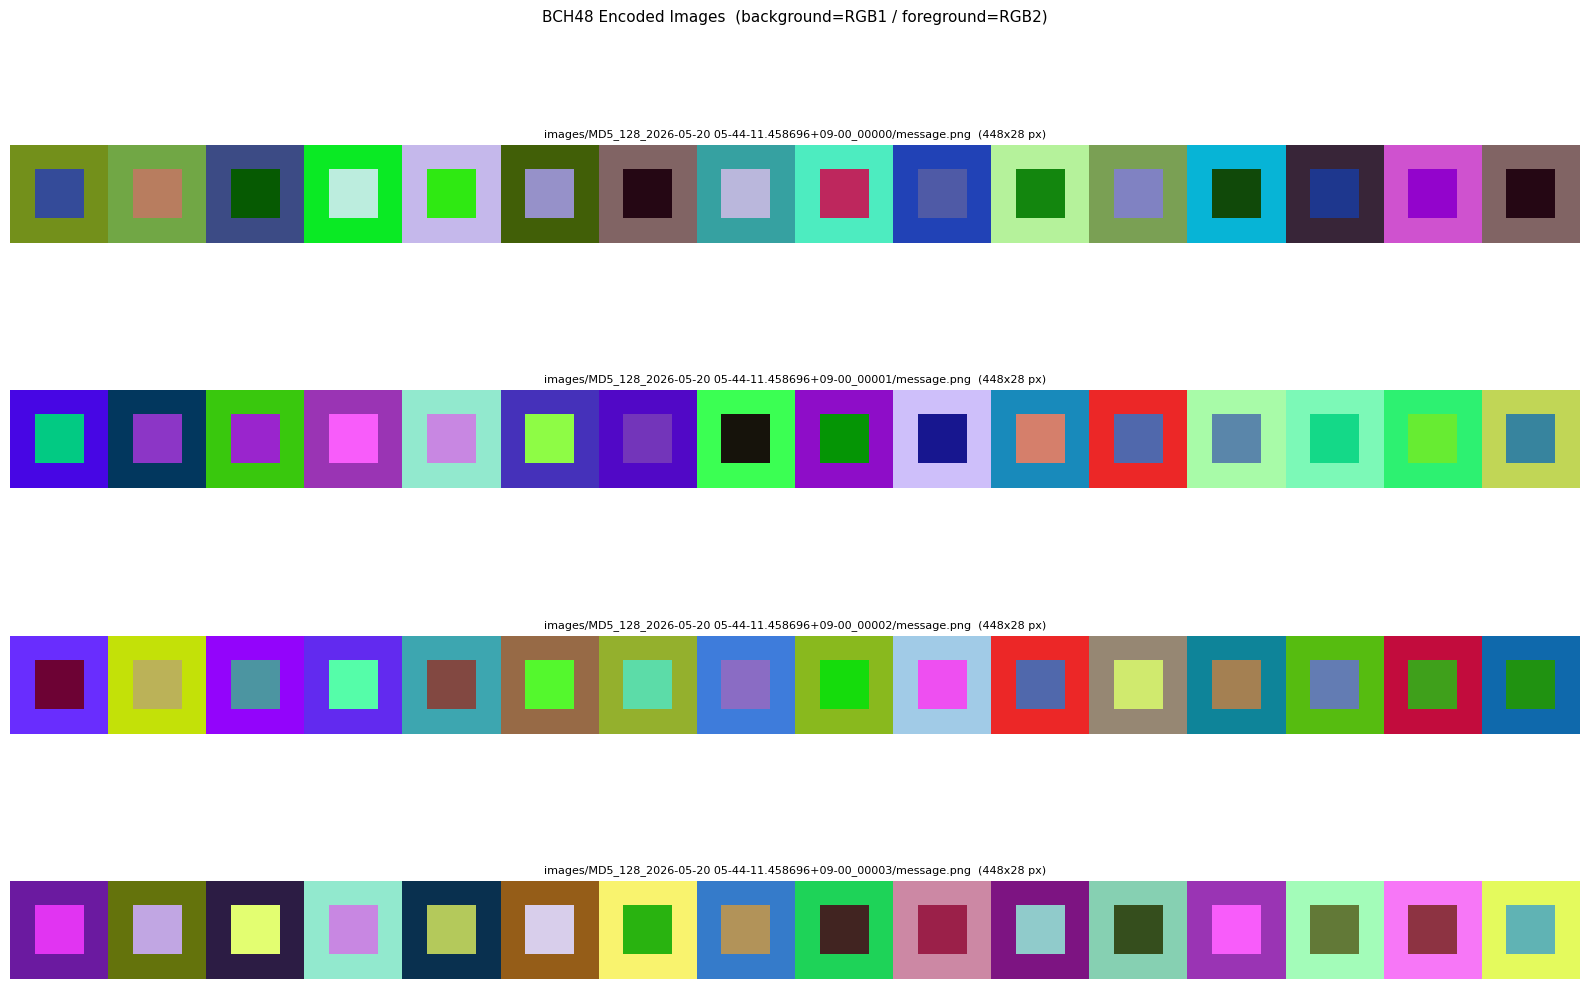

In [13]:
MAX_DISPLAY = 4

if png_files:
    n    = min(MAX_DISPLAY, len(png_files))
    fig, axes = plt.subplots(n, 1, figsize=(16, 2.8 * n))
    if n == 1:
        axes = [axes]

    for ax, p in zip(axes, png_files[:n]):
        with Image.open(p) as im:
            arr = np.array(im)
            title = p.parent.parent.name + '/' + p.parent.name + '/' + p.name
            title += '  (' + str(im.size[0]) + 'x' + str(im.size[1]) + ' px)'
        ax.imshow(arr)
        ax.set_title(title, fontsize=8)
        ax.axis('off')

    plt.suptitle('BCH48 Encoded Images  (background=RGB1 / foreground=RGB2)', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print('No PNG files to display.')

### 6-2. 바이트별 디코딩 신뢰도 & 정정 오류 수

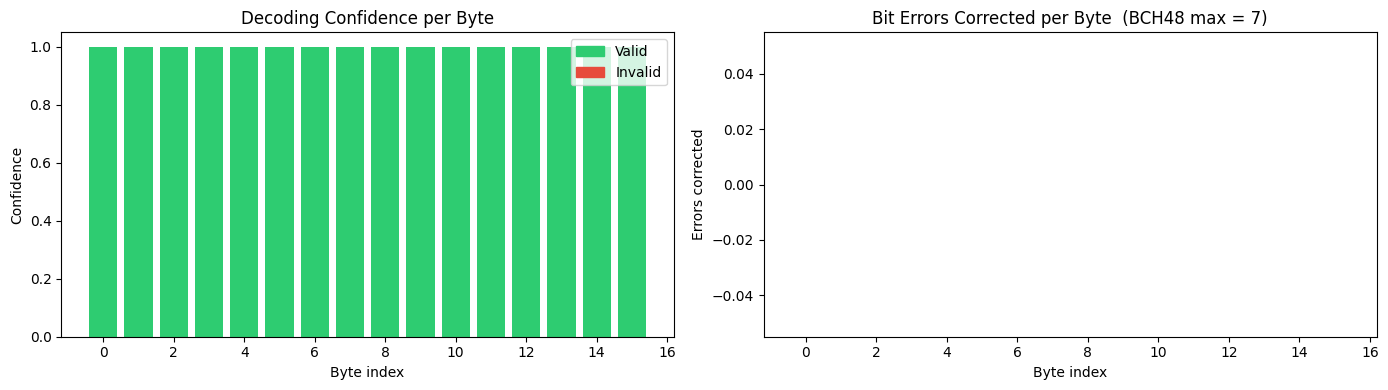

Summary : message.png
  Total bytes      : 16
  Valid bytes      : 16
  Avg confidence   : 1.0
  Max errors corr. : 0


In [14]:
if png_files and 'decode_results' in dir():
    byte_idx    = list(range(len(decode_results)))
    confidences = [r['confidence'] for r in decode_results]
    bar_colors  = ['#2ecc71' if r['valid'] else '#e74c3c' for r in decode_results]
    errors      = [r['errors_corrected'] for r in decode_results]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.bar(byte_idx, confidences, color=bar_colors)
    ax1.set_ylim(0, 1.05)
    ax1.set_xlabel('Byte index')
    ax1.set_ylabel('Confidence')
    ax1.set_title('Decoding Confidence per Byte')
    green_p = mpatches.Patch(color='#2ecc71', label='Valid')
    red_p   = mpatches.Patch(color='#e74c3c', label='Invalid')
    ax1.legend(handles=[green_p, red_p])

    ax2.bar(byte_idx, errors, color='#3498db')
    ax2.set_xlabel('Byte index')
    ax2.set_ylabel('Errors corrected')
    ax2.set_title('Bit Errors Corrected per Byte  (BCH48 max = 7)')

    plt.tight_layout()
    plt.show()

    print('Summary :', png_files[0].name)
    print('  Total bytes      :', len(decode_results))
    print('  Valid bytes      :', sum(r['valid'] for r in decode_results))
    print('  Avg confidence   :', round(sum(confidences) / len(confidences), 4))
    print('  Max errors corr. :', max(errors))
else:
    print('Run Section 4 first to populate decode_results.')

### 6-3. 블록별 배경 / 전경 색상 팔레트

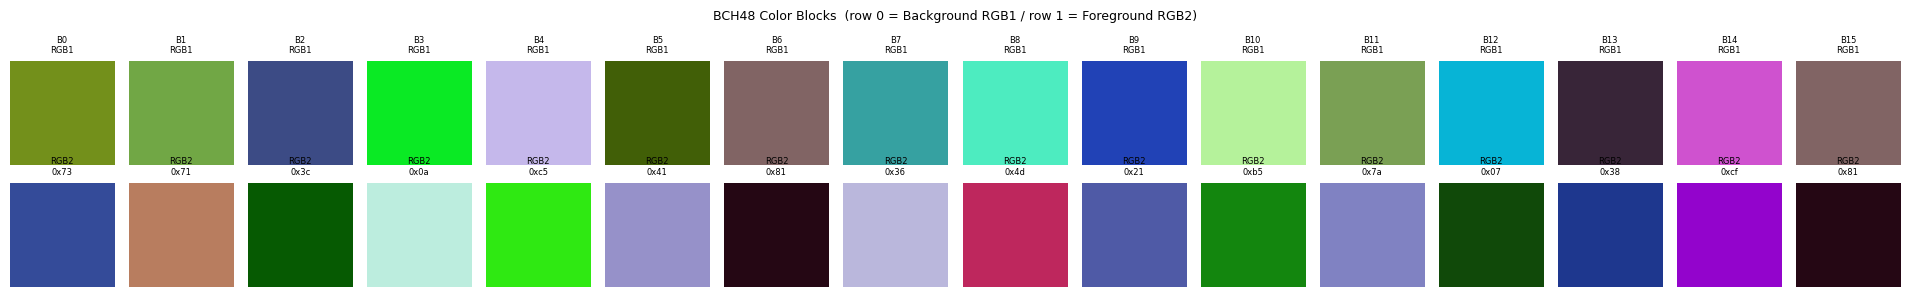

In [15]:
if png_files and 'decode_results' in dir():
    with Image.open(png_files[0]) as im:
        img_np = np.array(im.convert('RGB'))

    n_bytes  = len(decode_results)
    block_w  = 28

    fig, axes = plt.subplots(2, n_bytes, figsize=(n_bytes * 1.2, 3))
    fig.suptitle(
        'BCH48 Color Blocks  (row 0 = Background RGB1 / row 1 = Foreground RGB2)',
        fontsize=9
    )

    for i in range(n_bytes):
        # Background sample: pixel at (1, block_start+1) — always in the border region
        bg_pixel = img_np[1, i * block_w + 1].astype(float) / 255.0
        # Foreground sample: center pixel at (14, block_start+14) — inside the 14x14 fg square
        fg_pixel = img_np[14, i * block_w + 14].astype(float) / 255.0

        axes[0, i].imshow([[bg_pixel]])
        axes[0, i].axis('off')
        axes[0, i].set_title('B' + str(i) + '\nRGB1', fontsize=6)

        pay = decode_results[i]['payload']
        fg_label = '0x{:02x}'.format(pay) if pay is not None else 'None'
        axes[1, i].imshow([[fg_pixel]])
        axes[1, i].axis('off')
        axes[1, i].set_title('RGB2\n' + fg_label, fontsize=6)

    plt.tight_layout()
    plt.show()
else:
    print('Run Section 4 first to populate decode_results.')